# Basic Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load, view and preprocess data

In [2]:
df = pd.read_csv('data/housing.csv')
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


inspections:
- total_bedrooms: 207 missing values
- ocean_proximity: object

In [4]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [5]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

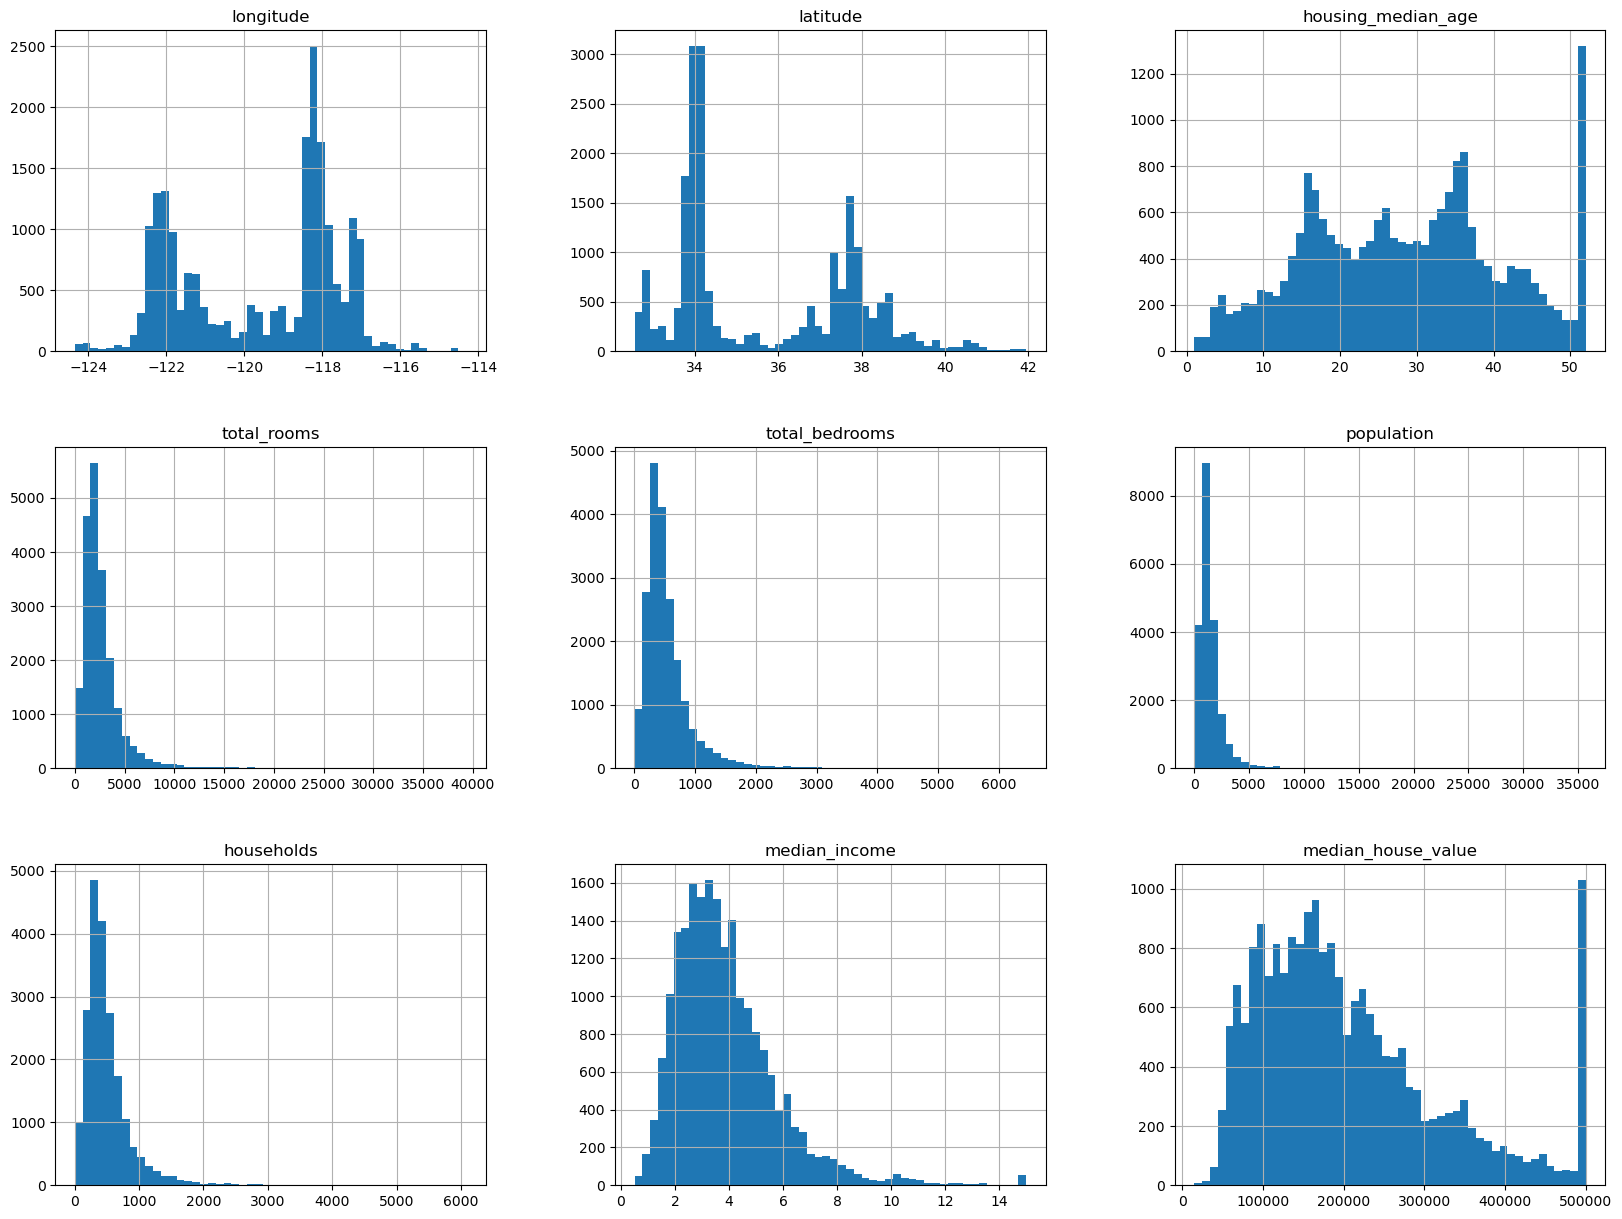

In [6]:
df.hist(bins=50, figsize=(20,15))

inspections:
- median_house_value is capped at $500,000 → bias the model, consider removing capped districts.
- median_house_age is also capped → model may learn a false upper limit.
- total_rooms, total_bedrooms, population, households are tail-heavy → transformation to bell-shaped distributions.
- features have very different scales → feature scaling.

# Creating an income category for stratified sampling
- Since median_income is one of the most important predictors of strat_train_set_copy prices, we need to make sure that the test set is representative of the overall income distribution in the dataset.
- To avoid this issue, we perform a stratified split based on the previously created income_cat attribute. StratifiedShuffleSplit ensures that each income category preserves the same proportion in both the training set and the test set, resulting in a more representative and reliable split.

<Axes: >

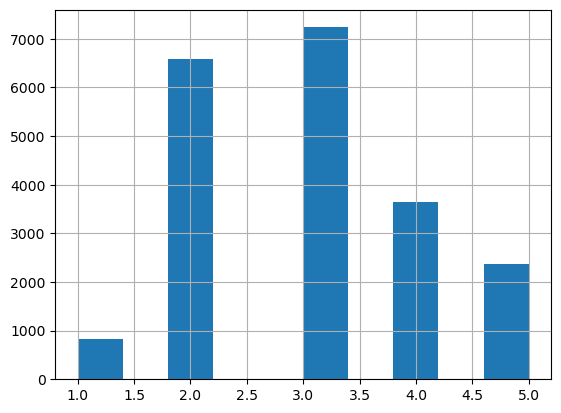

In [7]:
df['income_cat'] = pd.cut(df['median_income'],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

df['income_cat'].hist()

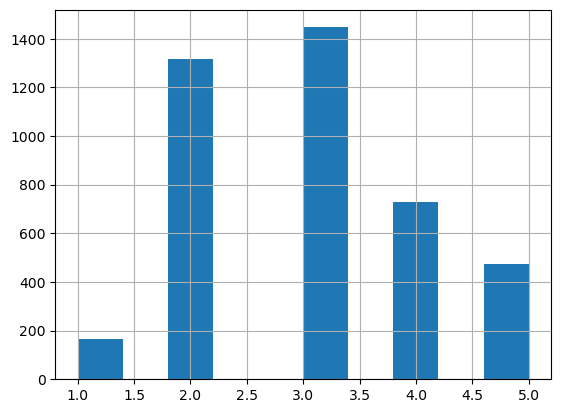

In [8]:
from sklearn.model_selection import StratifiedShuffleSplit

# Split train-test set
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=66)
for train_index, test_index in sss.split(df, df['income_cat']):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]

# Validation that the income category proportions are maintained
strat_test_set['income_cat'].hist()

# Drop income_cat attribute so the data is back to its original state
for splitted_set in (strat_train_set, strat_test_set):
    splitted_set.drop('income_cat', axis=1, inplace=True)

Inpsects:
- strat_test_set and original data set now have the same distribution in median_income range.

# Explore training_set

In [9]:
# Copy strat_train_set for exploration
strat_train_set_copy = strat_train_set.copy()

#### Visualizing Geographical Data
- strat_train_set_copy prices are encoded using color and population using marker size. 
- This produces a geographical heatmap showing that coastal areas tend to have much higher strat_train_set_copy prices.

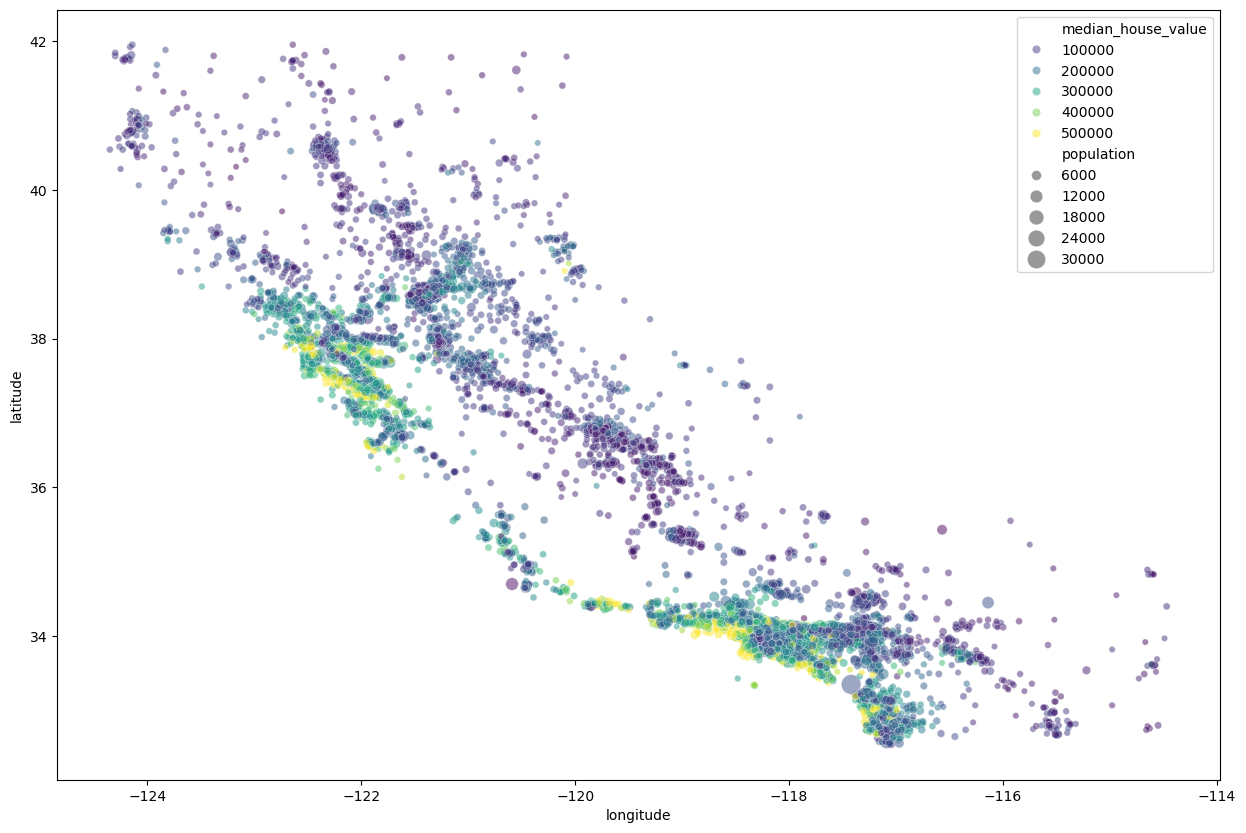

In [10]:
plt.figure(figsize=(15,10))
sns.scatterplot(
    data=strat_train_set_copy, 
    x='longitude', 
    y='latitude', 
    hue='median_house_value', 
    size='population', 
    sizes=(20, 200), 
    alpha=0.5, 
    palette='viridis')
plt.show()


#### Correlation analysis
- Examining the column corresponding to median_house_value reveals which features are most strongly associated with strat_train_set_copy prices.
- median_income shows the highest correlation, while attributes such as total_rooms and population exhibit much weaker relationships.

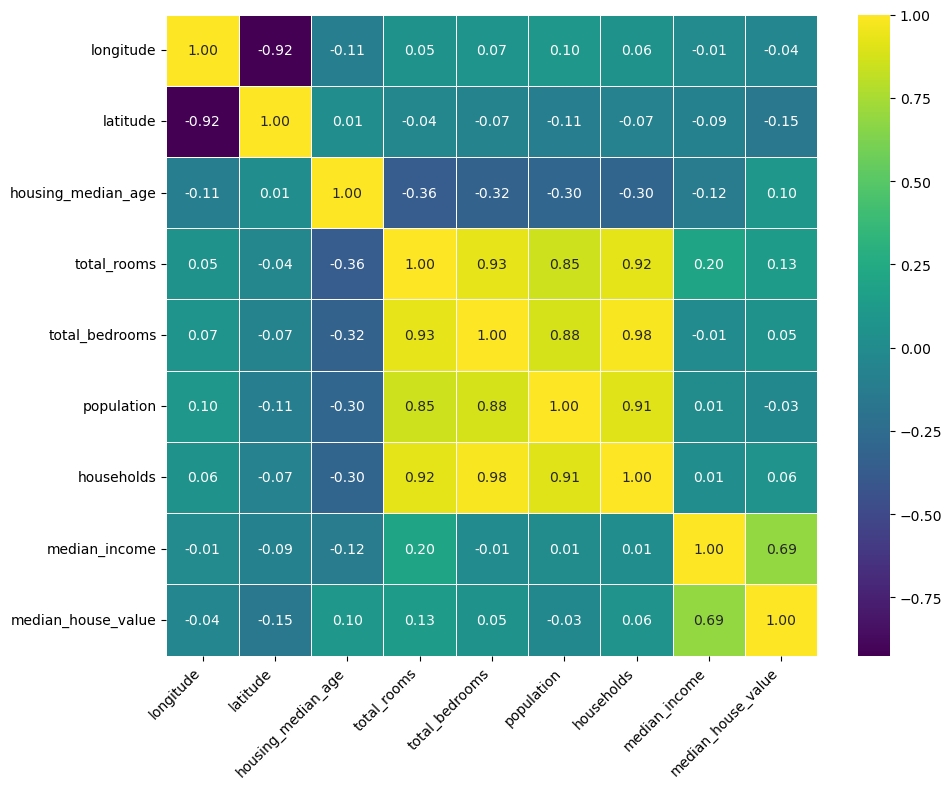

median_house_value    1.000000
median_income         0.686401
total_rooms           0.133075
housing_median_age    0.104063
households            0.064200
total_bedrooms        0.047993
population           -0.026521
longitude            -0.037705
latitude             -0.151189
Name: median_house_value, dtype: float64

In [11]:
# ocean_proximity is a categorical attribute, it must be removed before computing the correlation matrix.
strat_train_set_copy_numeric = strat_train_set_copy.drop('ocean_proximity', axis=1)
correlations_matrix = strat_train_set_copy_numeric.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlations_matrix,
    annot=True,
    cmap='viridis',
    fmt='.2f',
    linewidths=0.5
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
correlations_matrix['median_house_value'].sort_values(ascending=False)

Inspections:
- median_income shows the strongest positive correlation with median_house_value.
- Geographic attributes (longitude, latitude) show moderate correlations.
- total_rooms, total_bedrooms, population, and households are strongly correlated with each other, indicating multicollinearity.
- No other feature exhibits a strong direct correlation with strat_train_set_copy prices.


#### Feature engineering
Raw features such as total_rooms, total_bedrooms, and population do not directly reflect useful ratios or per-household information.
By combining these attributes, we obtain engineered features that often correlate more strongly with strat_train_set_copy prices.

The following three attributes are introduced:
- rooms_per_household: Represents the average number of rooms available per household.
- bedrooms_ratio: Measures the proportion of bedrooms relative to total rooms. 
- population_per_household: neighborhood density and living conditions, which may influence strat_train_set_copy prices.

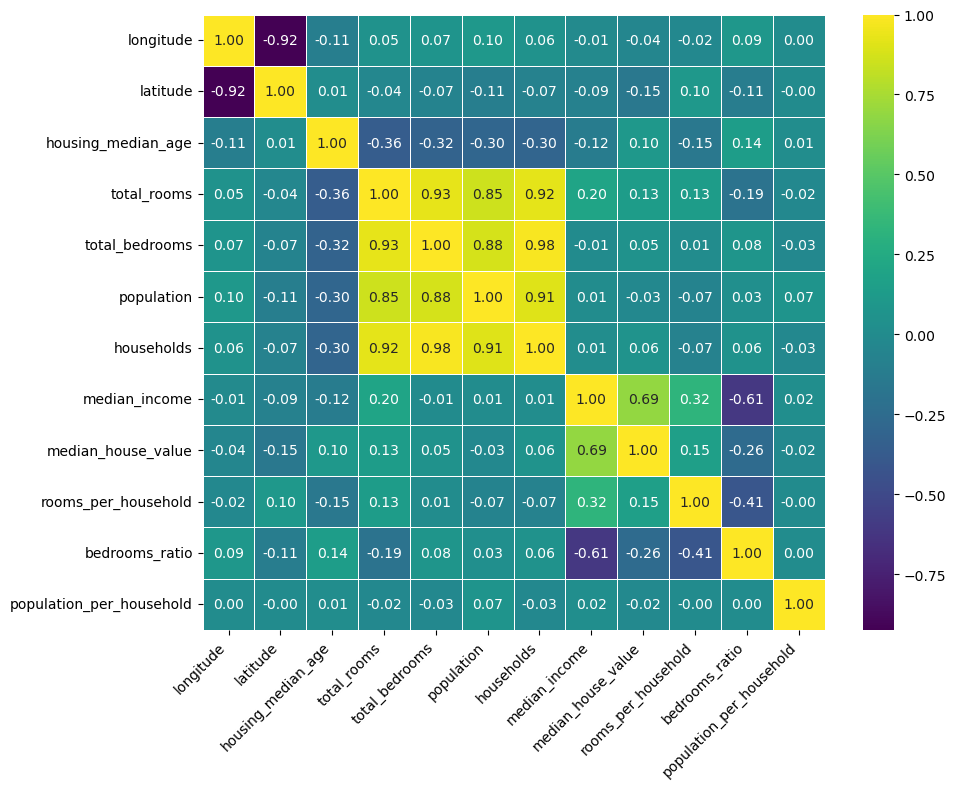

median_house_value          1.000000
median_income               0.686401
rooms_per_household         0.153984
total_rooms                 0.133075
housing_median_age          0.104063
households                  0.064200
total_bedrooms              0.047993
population_per_household   -0.020421
population                 -0.026521
longitude                  -0.037705
latitude                   -0.151189
bedrooms_ratio             -0.258131
Name: median_house_value, dtype: float64

In [12]:
strat_train_set_copy['rooms_per_household'] = strat_train_set_copy['total_rooms'] / strat_train_set_copy['households']
strat_train_set_copy['bedrooms_ratio'] = strat_train_set_copy['total_bedrooms'] / strat_train_set_copy['total_rooms']
strat_train_set_copy['population_per_household'] = strat_train_set_copy['population'] / strat_train_set_copy['households']

strat_train_set_copy_numeric = strat_train_set_copy.drop('ocean_proximity', axis=1)
correlations_matrix = strat_train_set_copy_numeric.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlations_matrix,
    annot=True,
    cmap='viridis',
    fmt='.2f',
    linewidths=0.5
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
correlations_matrix['median_house_value'].sort_values(ascending=False)


Inspections:
- rooms_per_household exhibits a higher correlation than the original total_rooms.
- Features such as total_rooms, housing_median_age, and households show weak positive correlations, but still contribute some signal.
- Attributes like total_bedrooms, population_per_household, population, and longitude have very weak correlations with the target. However, low linear correlation does not imply that these features are useless; they may contribute through nonlinear relationships or feature interactions.

# Clean data
Using full automated pipeline model

In [13]:
# Split features and labels
strat_X_train = strat_train_set_copy.drop('median_house_value', axis=1)
strat_y_train = strat_train_set_copy['median_house_value']

In [14]:
# All columns except 'ocean_proximity' are numeric
numeric_features = list(strat_X_train.drop('ocean_proximity', axis=1).columns)
# The only categorical attribute is 'ocean_proximity'
categorical_features = ['ocean_proximity']
print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)

Numeric features: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_ratio', 'population_per_household']
Categorical features: ['ocean_proximity']


# Add features automatically

In [15]:
from sklearn.base import BaseEstimator, TransformerMixin

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, feature_names):
        self.feature_names = feature_names

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        df = pd.DataFrame(X, columns=self.feature_names)
        df['rooms_per_household'] = df['total_rooms'] / df['households']
        df['population_per_household'] = df['population'] / df['households']
        df['bedrooms_ratio'] = df['total_bedrooms'] / df['total_rooms']
                
        return df.to_numpy()

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

# Pipeline to process numeric features:
# For numeric features:
# 1) fill missing values with median
# 2) standardize each numeric feature
numeric_features = list(strat_train_set.drop(columns=['ocean_proximity', 'median_house_value'], axis=1).columns)
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('attr_adder', CombinedAttributesAdder(numeric_features)),
    ('scaler', StandardScaler()),
])
# For categorial features:
# 1) encodes categorical features using one-hot encoding
categorical_pipeline = Pipeline([
    ('onehotencode', OneHotEncoder()),
])

# ColumnTransformer applies different transformations to different column sets:
# 1) numeric_pipeline for numeric column(s)
# 2) categorical_pipeline for categorical column(s)
full_pipeline = ColumnTransformer([
        ('num', numeric_pipeline, numeric_features),
        ('cat', categorical_pipeline, categorical_features),
])
print('Full pipeline review:', full_pipeline)

Full pipeline review: ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('attr_adder',
                                                  CombinedAttributesAdder(feature_names=['longitude',
                                                                                         'latitude',
                                                                                         'housing_median_age',
                                                                                         'total_rooms',
                                                                                         'total_bedrooms',
                                                                                         'population',
                                                                                         'households

In [17]:
# # Apply the full pipeline to the training set and test set
# X_train_preprocessed = full_pipeline.fit_transform(strat_X_train)

# # Create the new features in the test set
# strat_test_set_copy = strat_test_set.copy()
# strat_test_set_copy['rooms_per_household'] = strat_test_set_copy['total_rooms'] / strat_test_set_copy['households']
# strat_test_set_copy['bedrooms_ratio'] = strat_test_set_copy['total_bedrooms'] / strat_test_set_copy['total_rooms']
# strat_test_set_copy['population_per_household'] = strat_test_set_copy['population'] / strat_test_set_copy['households']

# X_test_preprocessed = full_pipeline.transform(strat_test_set_copy.drop('median_house_value', axis=1))
# print('Columns after transformation:', full_pipeline.get_feature_names_out())
# print('Final prepared training set (np.darray):', X_train_preprocessed)

# Prepare sets

In [18]:
# 
X_train = strat_train_set.drop('median_house_value', axis=1)
y_train = strat_train_set['median_house_value']

X_test  = strat_test_set.drop('median_house_value', axis=1)
y_test  = strat_test_set['median_house_value']
print(full_pipeline)

X_train_preprocessed = full_pipeline.fit_transform(X_train)
X_test_preprocessed = full_pipeline.transform(X_test)


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('attr_adder',
                                                  CombinedAttributesAdder(feature_names=['longitude',
                                                                                         'latitude',
                                                                                         'housing_median_age',
                                                                                         'total_rooms',
                                                                                         'total_bedrooms',
                                                                                         'population',
                                                                                         'households',
                   

# Train linear model

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RidgeCV, LassoCV

linear_reg = LinearRegression().fit(X_train_preprocessed, y_train)
ridge_reg = RidgeCV(alphas=[0.01, 0.1, 1, 10]).fit(X_train_preprocessed, y_train)
lasso_reg = LassoCV(cv=5).fit(X_train_preprocessed, y_train)

**Assessment:**
- **LinearRegression**: Standard OLS regression with no regularization. Fast to train but prone to overfitting with many features.
- **RidgeCV**: L2 regularization with built-in cross-validation for alpha selection. Shrinks coefficients to reduce multicollinearity effects.
- **LassoCV**: L1 regularization with cross-validation. Performs feature selection by driving some coefficients to zero.

All three models are fitted on the preprocessed training data in a single step using `.fit()`.

In [20]:


print('Linear R²:', linear_reg.score(X_test_preprocessed, y_test))
print('Ridge R²:',  ridge_reg.score(X_test_preprocessed, y_test))
print('Lasso R²:',  lasso_reg.score(X_test_preprocessed, y_test))


Linear R²: 0.6658131049820617
Ridge R²: 0.6658179675482223
Lasso R²: 0.6652743496758553


**Assessment:**
- R² (coefficient of determination) measures the proportion of variance in the target variable explained by the model.
- Values close to 1.0 indicate excellent fit; values near 0 suggest the model explains little variance.
- All three linear models show similar R² scores, indicating that regularization has minimal impact on this dataset.
- The relatively modest R² values suggest that linear models may not fully capture the complexity of housing price relationships.

In [ ]:
from sklearn.metrics import mean_squared_error
y_pred_linear = linear_reg.predict(X_test_preprocessed)
y_pred_ridge  = ridge_reg.predict(X_test_preprocessed)
y_pred_lasso  = lasso_reg.predict(X_test_preprocessed)
mse_linear = mean_squared_error(y_test, y_pred_linear)
mse_ridge  = mean_squared_error(y_test, y_pred_ridge)
mse_lasso  = mean_squared_error(y_test, y_pred_lasso)
print('Linear RMSE:', np.sqrt(mse_linear))
print('Ridge RMSE:',  np.sqrt(mse_ridge))
print('Lasso RMSE:',  np.sqrt(mse_lasso))

Linear RMSE: 66404.33345814844
Ridge RMSE: 66403.85035027648
Lasso RMSE: 66457.83836859804


Mean square error in all models are around 66,400 which represent underfittng

# Train tree models

In [22]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

**Assessment:**
- **DecisionTreeRegressor**: A non-linear model that partitions the feature space into regions and predicts the mean target value within each region. Prone to overfitting without proper pruning.
- **RandomForestRegressor**: An ensemble of decision trees that reduces overfitting by averaging predictions from multiple trees trained on bootstrapped samples with random feature subsets.

In [23]:
decision_tree = DecisionTreeRegressor().fit(X_train_preprocessed, y_train)
random_forest = RandomForestRegressor().fit(X_train_preprocessed, y_train)

In [24]:
y_pred_dt = decision_tree.predict(X_test_preprocessed)
y_pred_rf = random_forest.predict(X_test_preprocessed)

In [25]:
mse_dt = mean_squared_error(y_test, y_pred_dt)
mse_rf = mean_squared_error(y_test, y_pred_rf)

print('Decision Tree RMSE:', np.sqrt(mse_dt))
print('Random Forest RMSE:', np.sqrt(mse_rf))

Decision Tree RMSE: 69432.43243106446
Random Forest RMSE: 47506.92577004743


**Assessment:**
- Decision Tree shows higher RMSE compared to Random Forest, indicating overfitting on the training data and poor generalization.
- Random Forest achieves lower RMSE due to its ensemble approach, which averages out individual tree errors and reduces variance.
- The significant improvement from Decision Tree to Random Forest demonstrates the power of ensemble methods in reducing overfitting.

# Cross-validation for tree models

In [26]:
from sklearn.model_selection import cross_val_score
dt_score = cross_val_score(decision_tree, X_train_preprocessed, y_train, scoring='neg_mean_squared_error', cv=10)
rf_score = cross_val_score(random_forest, X_train_preprocessed, y_train, scoring='neg_mean_squared_error', cv=10)
dt_rmse_scores = np.sqrt(-dt_score)
rf_rmse_scores = np.sqrt(-rf_score)
print('Decision Tree Cross-Validation RMSE:', dt_rmse_scores)
print('Random Forest Cross-Validation RMSE:', rf_rmse_scores)

Decision Tree Cross-Validation RMSE: [75013.7734805  68039.36122975 70289.57905241 69665.20865941
 71275.80054519 69206.2983827  69725.82707571 71161.73421948
 69757.8043953  70451.53819017]
Random Forest Cross-Validation RMSE: [52773.33404035 50586.42015877 52746.63178644 51344.28299905
 48473.51926742 51194.26385697 49177.93294012 50782.42271224
 49219.57902634 47920.75733872]


**Assessment:**
- Cross-validation provides a more robust estimate of model performance by training and evaluating on multiple data splits.
- 10-fold CV divides data into 10 parts, training on 9 and testing on 1, repeated 10 times with different test folds.
- `neg_mean_squared_error` is used because scikit-learn optimizes for maximum scores; negation converts MSE (lower is better) to a maximizable metric.
- The RMSE scores across folds show model stability; high variance indicates sensitivity to data splits.

# Grid-search for Random Forests

In [27]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [5, 12, 30],
    'max_features': [2, 4, 6, 8],
    'n_estimators': [3, 5, 10],
    'max_features': [2, 4, 6],
    }

grid_search = RandomizedSearchCV(
    estimator=random_forest,
    param_distributions=param_grid,
    n_iter=10,
    scoring='neg_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train_preprocessed, y_train)

d:\miniconda3\envs\venv-test\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,estimator,RandomForestRegressor()
,param_distributions,"{'max_features': [2, 4, ...], 'n_estimators': [3, 5, ...]}"
,n_iter,10
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


**Assessment:**
- **RandomizedSearchCV** randomly samples hyperparameter combinations, more efficient than exhaustive GridSearchCV for large parameter spaces.
- `n_iter=10` limits to 10 random combinations, balancing computation time and search coverage.
- `cv=5` performs 5-fold cross-validation for each parameter combination to ensure robust evaluation.
- `n_jobs=-1` enables parallel processing across all CPU cores for faster execution.
- `return_train_score=True` allows comparison of train vs validation scores to detect overfitting.

In [28]:
grid_search.best_params_

{'n_estimators': 10, 'max_features': 6}

**Assessment:**
- `best_params_` returns the hyperparameter combination that achieved the lowest cross-validated error during the search.
- These optimal parameters represent the best trade-off between model complexity and generalization performance.
- The selected `n_estimators` and `max_features` values can now be used to train the final model.

In [29]:
grid_search.best_estimator_

,n_estimators,10
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,6
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**Assessment:**
- `best_estimator_` returns the fully trained model with the optimal hyperparameters found during the search.
- This estimator can be used directly for predictions without needing to retrain.
- The displayed model shows all parameters including both the optimized ones and default values for other hyperparameters.
- This model represents the best-performing Random Forest configuration discovered through the randomized search process.